# Adult Census Income - Exploration et visualisation (EDA)
Objectif : comprendre les données **avant** de les modifier. Place `adult.data` et `adult.test` dans le même dossier que ce notebook.

## 0. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Les fichiers adult.data et adult.test doivent être dans le même dossier que le notebook
cols = ["age","workclass","fnlwgt","education","education-num","marital-status","occupation",
        "relationship","race","sex","capital-gain","capital-loss","hours-per-week","native-country","income"]
train = pd.read_csv("adult.data", names=cols, skipinitialspace=True)
test  = pd.read_csv("adult.test", names=cols, skipinitialspace=True, skiprows=1)  # 1ère ligne = commentaire
df = pd.concat([train, test], ignore_index=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1. Caractéristiques principales du dataset

In [3]:
print("Dimensions :", df.shape)
df.info()

Dimensions : (48842, 15)
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [4]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print("Numériques  :", num_cols)
print("Catégorielles :", cat_cols)
print("Doublons :", df.duplicated().sum())

Numériques  : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Catégorielles : ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Doublons : 29


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [20]:
df.describe(exclude="number").T

,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
sex,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,4,<=50K,24720


**Interprétation :** Le dataset (train + test) contient 48 842 lignes et 15 variables : 6 numériques (age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week) et 9 catégorielles (dont la cible income). On trouve 29 doublons. Les valeurs manquantes sont codées `?`, donc invisibles pour `isna()`.

## 2. Distributions des variables
### 2.1 Cible (income)

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


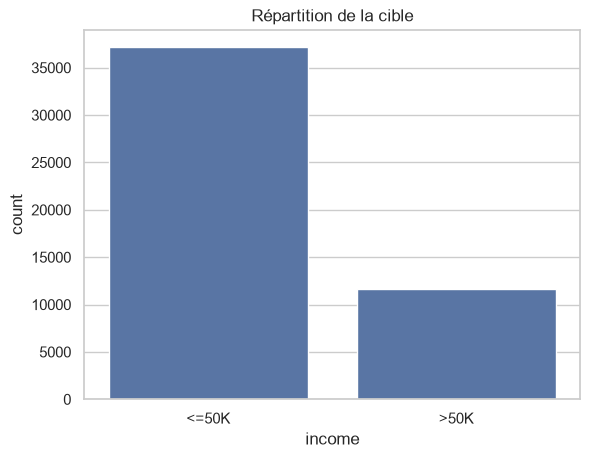

In [7]:
# La cible contient <=50K, <=50K., >50K, >50K. (le point vient du fichier test)
print(df["income"].value_counts())

# Version normalisée uniquement pour l'affichage (le vrai nettoyage se fait en préparation)
income_clean = df["income"].astype(str).str.strip().str.replace(".", "", regex=False)
print(income_clean.value_counts(normalize=True).round(3))

sns.countplot(x=income_clean, order=["<=50K", ">50K"])
plt.title("Répartition de la cible")
plt.show()

**Interprétation :** Après normalisation, 76,1 % des personnes gagnent <=50K contre 23,9 % pour >50K. Les classes sont déséquilibrées : l'accuracy seule serait trompeuse (prédire toujours <=50K donne déjà 76 %), on utilisera F1, recall, AUC et class_weight ou SMOTE.

### 2.2 Variables numériques

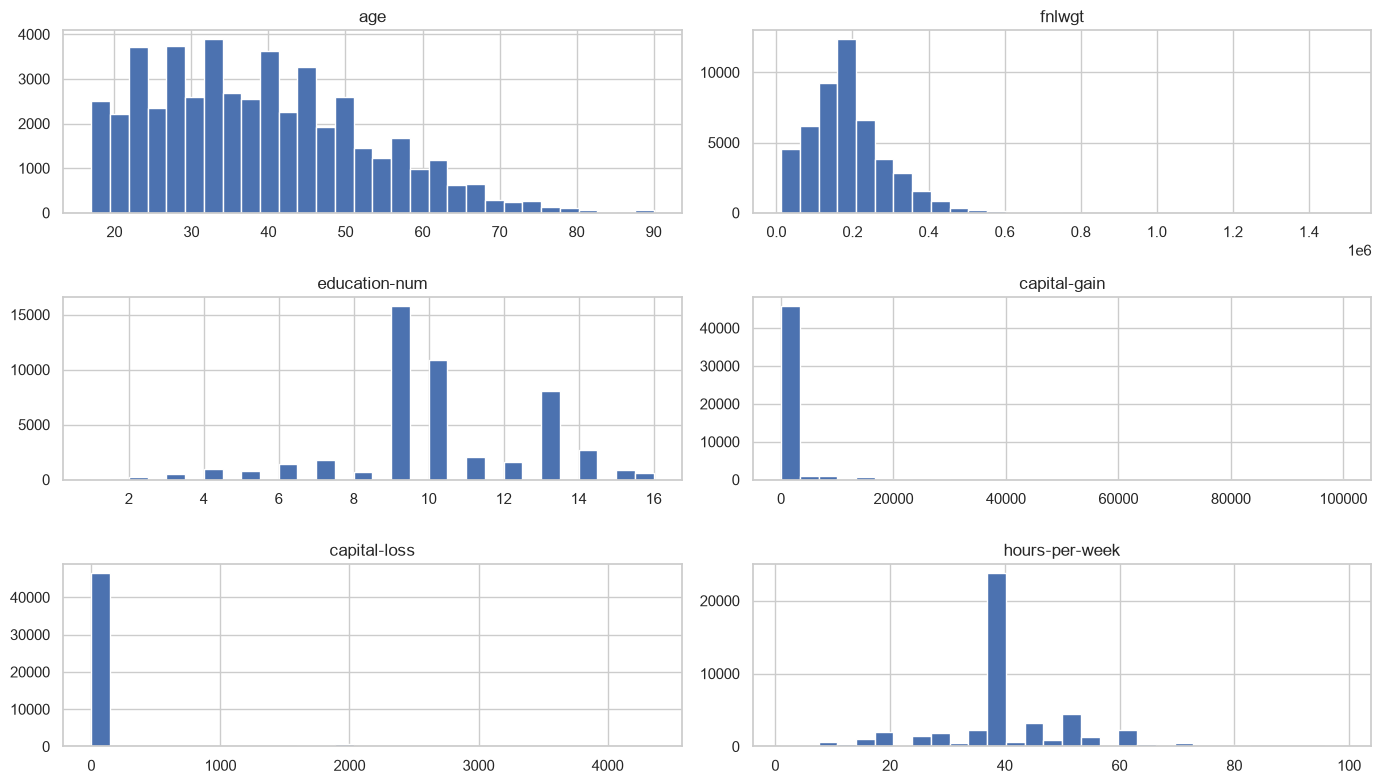

In [8]:
df[num_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

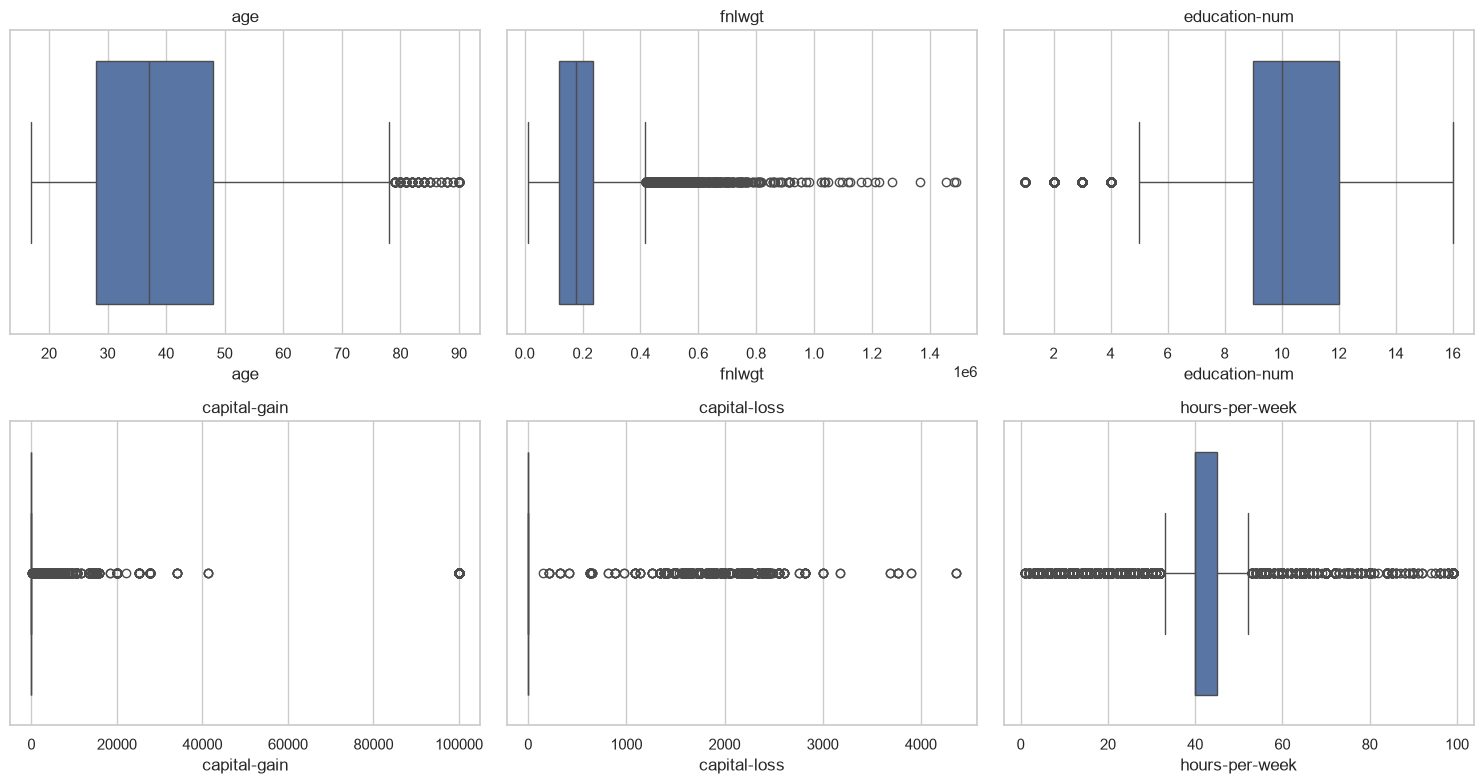

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(x=df[c], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

In [10]:
# Asymétrie et part de zéros
print(df[num_cols].skew().round(2))
print("\nPart de zéros :")
for c in ["capital-gain", "capital-loss"]:
    print(c, ":", round((df[c] == 0).mean() * 100, 1), "%")

age                0.56
fnlwgt             1.44
education-num     -0.32
capital-gain      11.89
capital-loss       4.57
hours-per-week     0.24
dtype: float64

Part de zéros :
capital-gain : 91.7 %
capital-loss : 95.3 %


**Interprétation :** capital-gain vaut 0 pour 91,7 % des personnes et capital-loss pour 95,3 %. Leur asymétrie est très forte (skew de 11,9 et 4,6) => transformation log1p ou variable binaire en préparation. age (0,56) et hours-per-week (0,24) sont peu asymétriques. fnlwgt (skew 1,44) est un poids d'échantillonnage, peu informatif.

### 2.3 Variables catégorielles

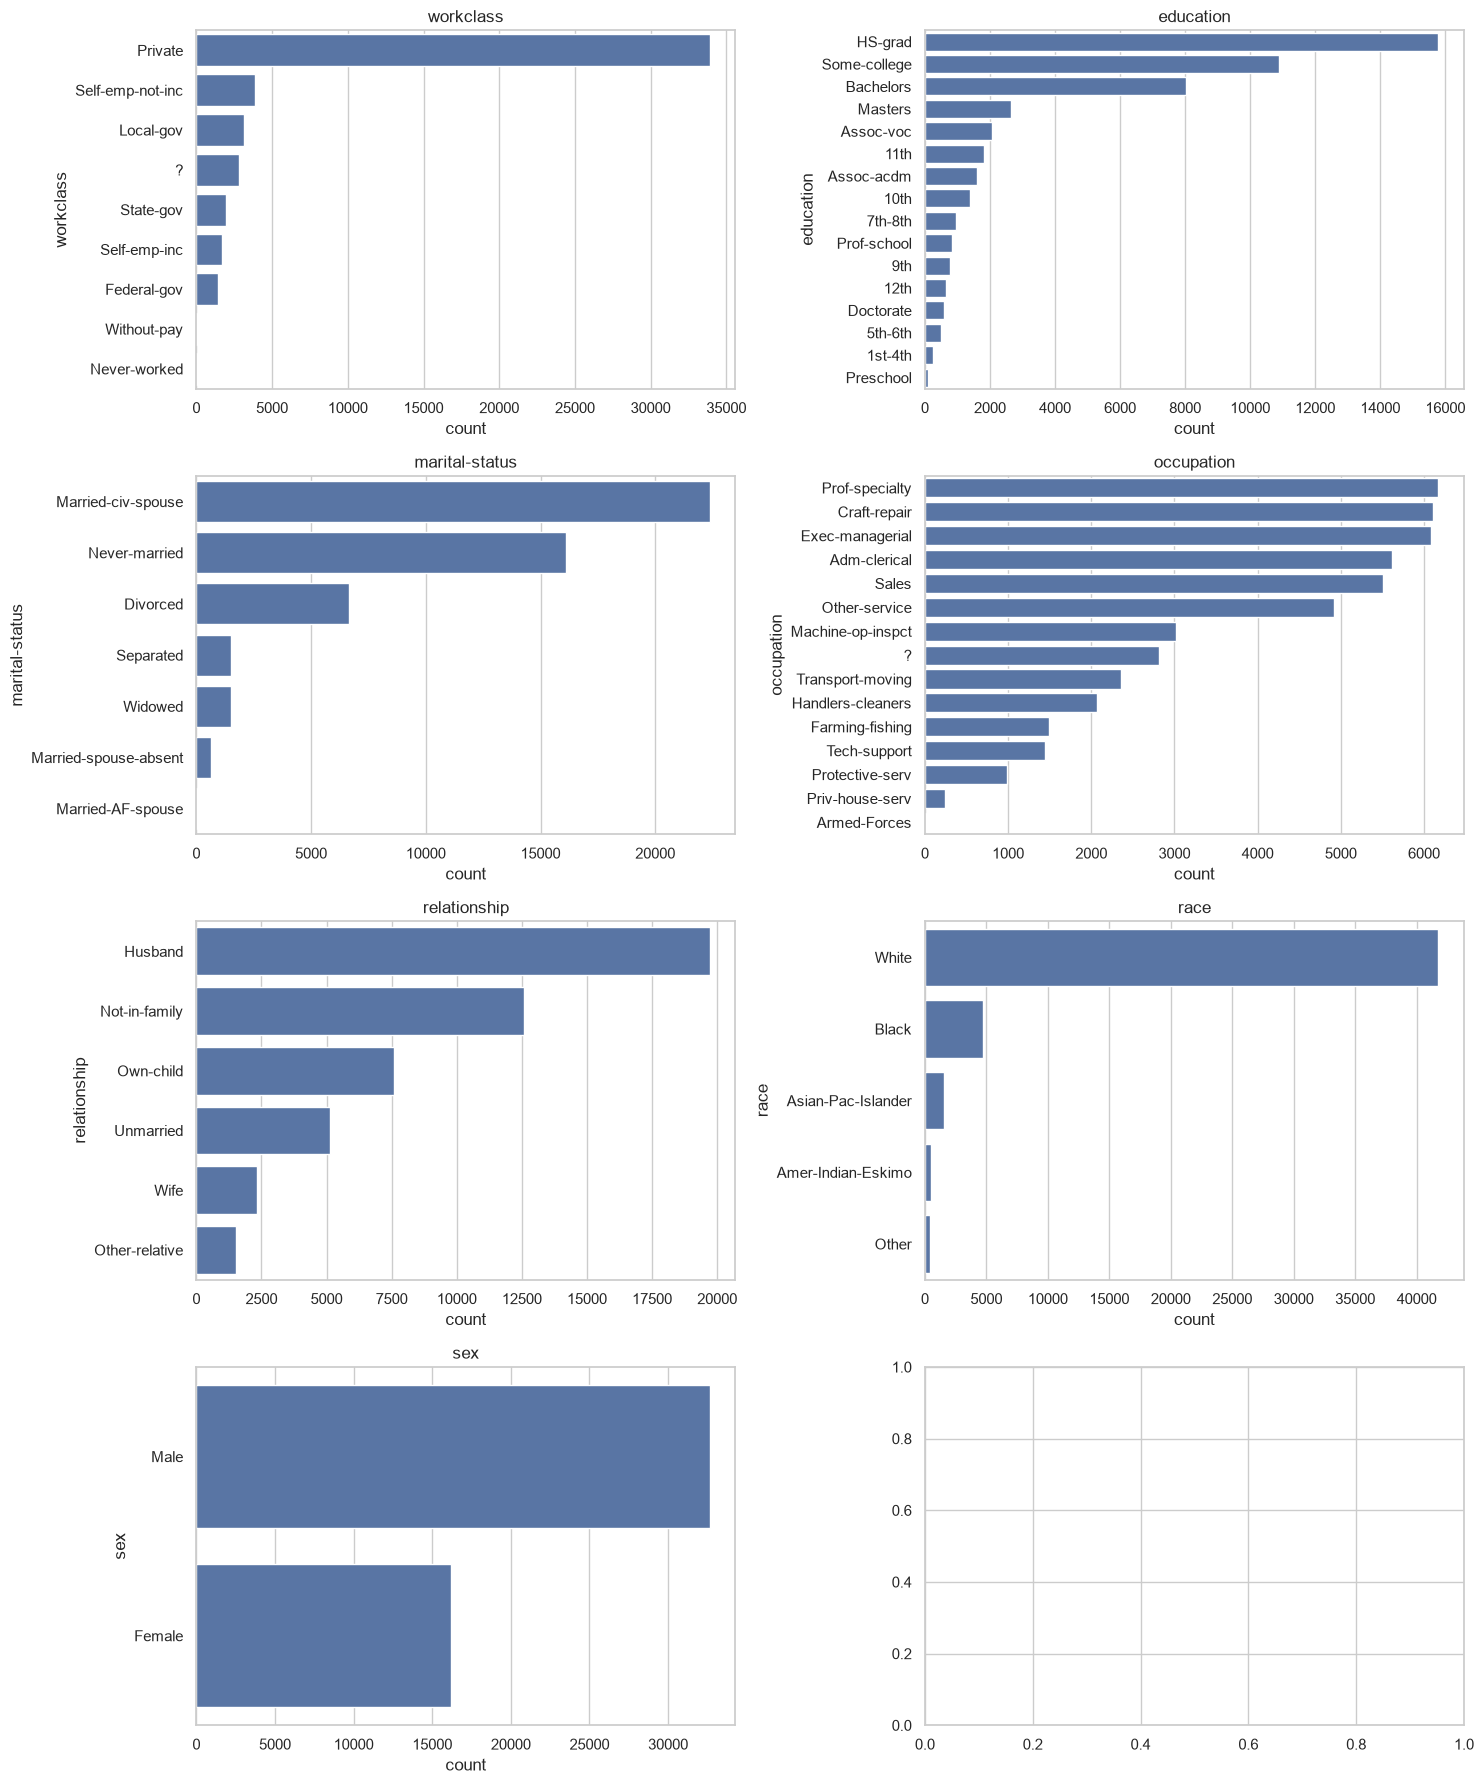

In [11]:
cat_plot = [c for c in cat_cols if c not in ["income", "native-country"]]
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
for ax, c in zip(axes.ravel(), cat_plot):
    order = df[c].value_counts().index
    sns.countplot(data=df, y=c, order=order, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

In [12]:
# native-country : très déséquilibré
print(df["native-country"].value_counts(normalize=True).head(5).round(3))

native-country
United-States    0.897
Mexico           0.019
?                0.018
Philippines      0.006
Germany          0.004
Name: proportion, dtype: float64


**Interprétation :** native-country est dominé par United-States (89,7 %), les autres pays sont très minoritaires => regroupement US / Autre pour éviter des dizaines de colonnes One-Hot quasi vides. Le secteur Private domine aussi workclass.

## 3. Relations entre variables
### 3.1 Corrélations

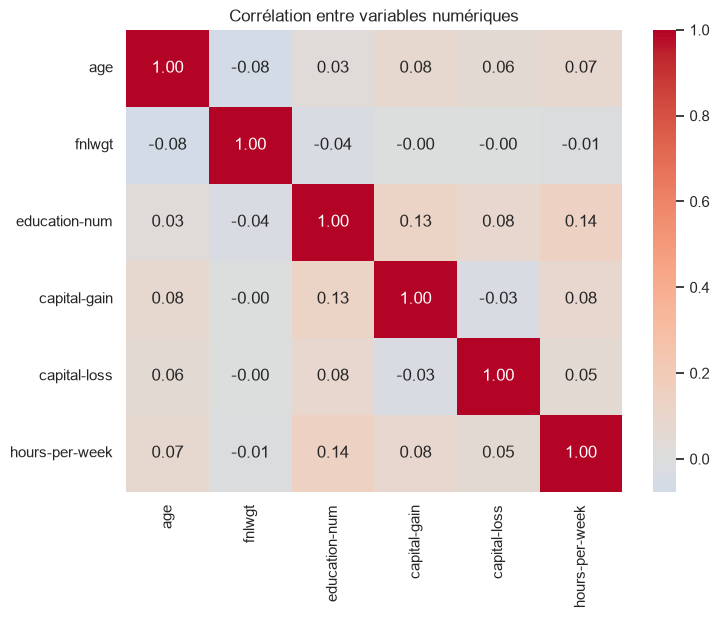

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélation entre variables numériques")
plt.show()

**Interprétation :** Les corrélations entre numériques sont faibles (aucune forte hors diagonale), donc pas de multicolinéarité gênante. La plus notable : education-num et hours-per-week (0,14). fnlwgt n'est corrélée à rien.

### 3.2 Variables numériques vs revenu

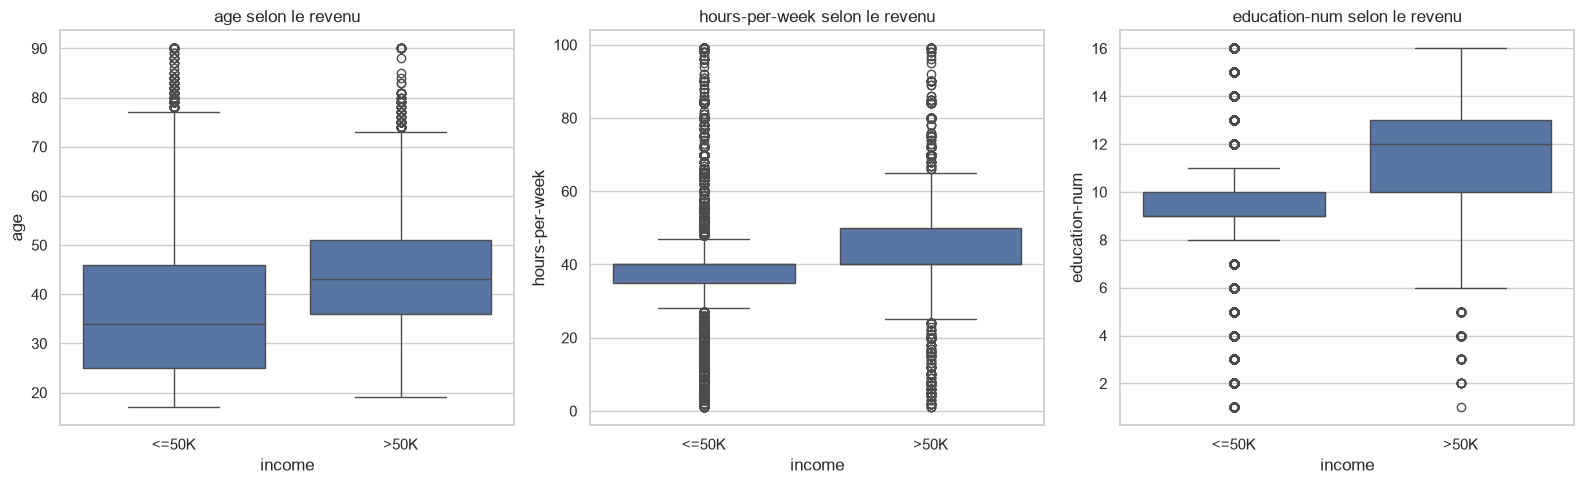

In [14]:
d = df.copy()
d["income"] = income_clean
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, c in zip(axes, ["age", "hours-per-week", "education-num"]):
    sns.boxplot(data=d, x="income", y=c, order=["<=50K", ">50K"], ax=ax)
    ax.set_title(f"{c} selon le revenu")
plt.tight_layout()
plt.show()

**Interprétation :** Les >50K sont en moyenne plus âgés (44,3 ans contre 36,9), travaillent plus (45,5 h contre 38,8 h) et sont plus diplômés (education-num 11,6 contre 9,6). Ces trois variables sont donc discriminantes pour la classification.

### 3.3 Variables catégorielles vs revenu

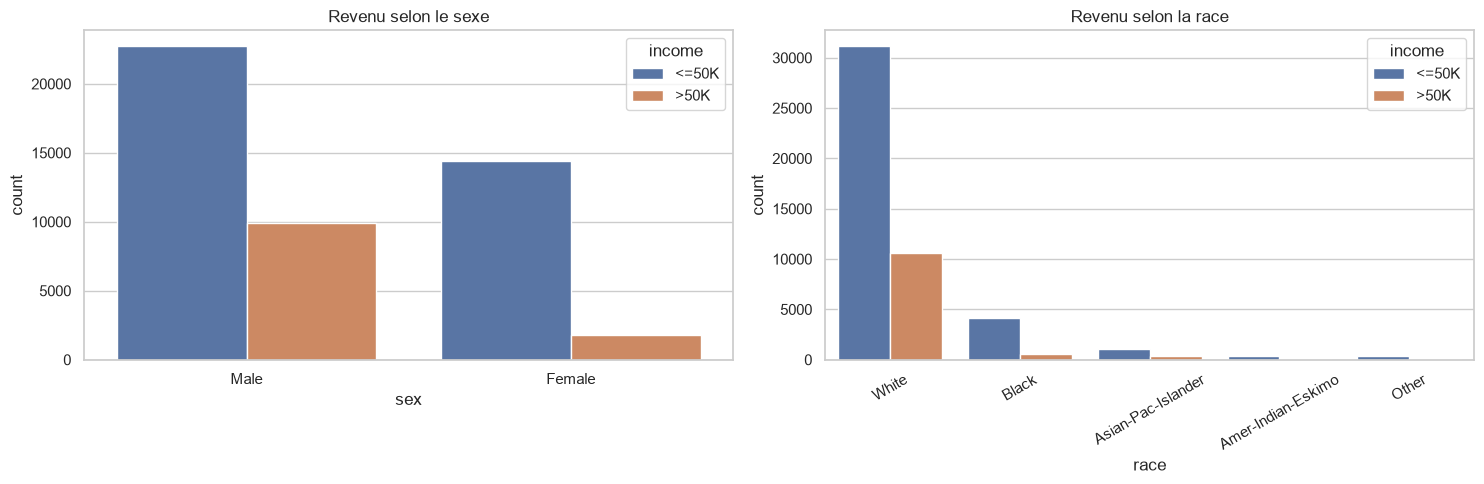

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=d, x="sex", hue="income", hue_order=["<=50K", ">50K"], ax=axes[0])
axes[0].set_title("Revenu selon le sexe")
sns.countplot(data=d, x="race", hue="income", hue_order=["<=50K", ">50K"], ax=axes[1])
axes[1].set_title("Revenu selon la race")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

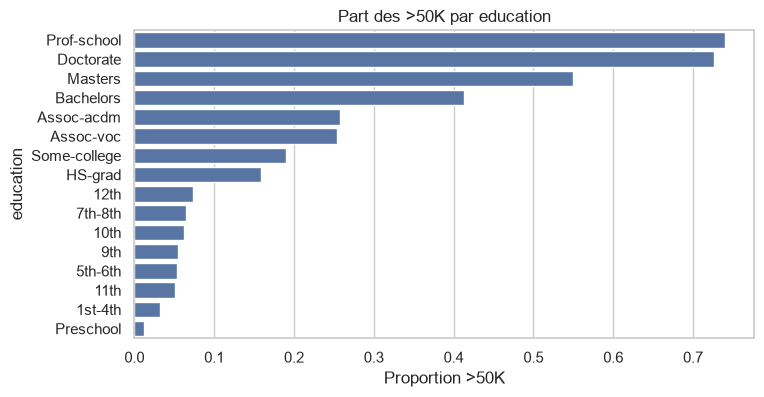

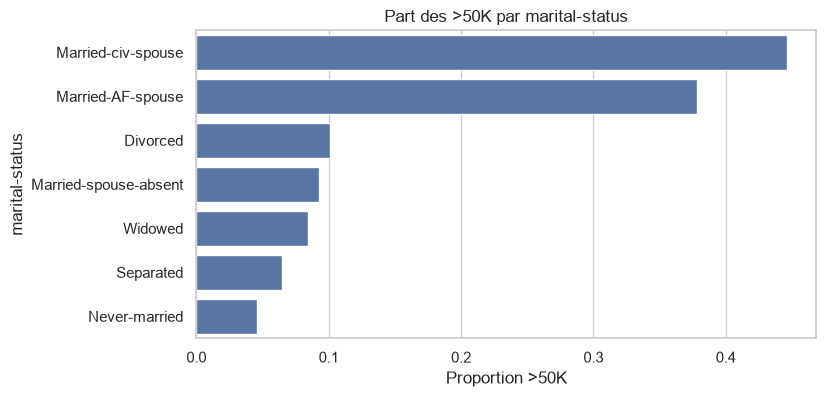

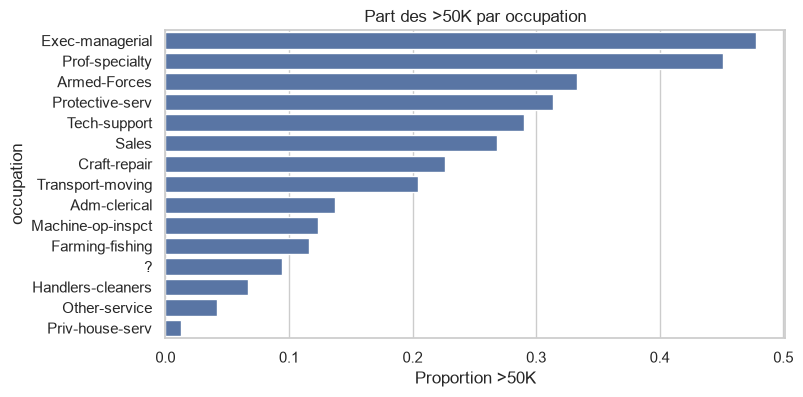

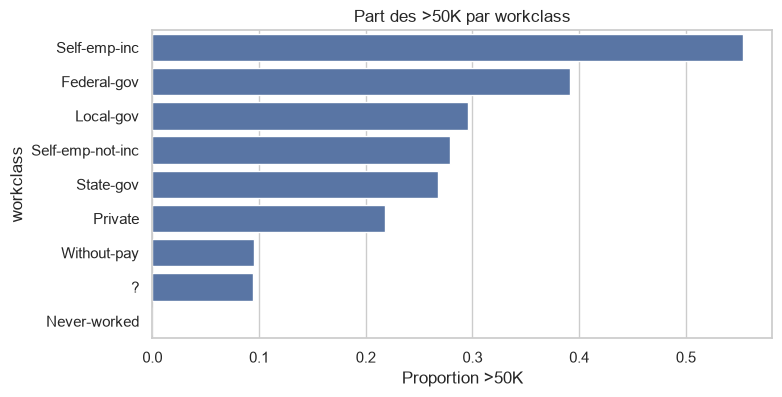

In [16]:
# Taux de revenu >50K par modalité
for c in ["education", "marital-status", "occupation", "workclass"]:
    rate = (d.assign(high=(d["income"] == ">50K")).groupby(c)["high"].mean()
              .sort_values(ascending=False))
    plt.figure(figsize=(8, 4))
    sns.barplot(x=rate.values, y=rate.index)
    plt.title(f"Part des >50K par {c}")
    plt.xlabel("Proportion >50K")
    plt.show()

**Interprétation :** 30,4 % des hommes gagnent >50K contre 10,9 % des femmes. Les personnes mariées (Married-civ-spouse : 44,6 %) sont bien au-dessus des autres statuts (6 à 10 %). Le taux monte avec le diplôme : Prof-school 74 %, Doctorate 73 %, Masters 55 %, Bachelors 41 %. Les Self-emp-inc (55 %) et Federal-gov (39 %) dominent côté workclass. Attention : sexe et statut marital sont liés (biais possible à discuter).

## 4. Détection des anomalies
### 4.1 Valeurs manquantes

In [17]:
# Les manquants peuvent être NaN ou "?" selon la méthode de chargement
missing = df.isna().sum() + (df.astype(str).apply(lambda s: s.str.strip() == "?")).sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print((missing / len(df) * 100).round(2).astype(str) + " %")

occupation        2809
workclass         2799
native-country     857
dtype: int64
occupation        5.75 %
workclass         5.73 %
native-country    1.75 %
dtype: str


**Interprétation :** 2 799 manquants dans workclass (5,7 %), 2 809 dans occupation (5,8 %) et 857 dans native-country (1,8 %). Ce sont des variables catégorielles avec peu de manquants, souvent sur les mêmes lignes => imputation par le mode ou catégorie Unknown en préparation.

### 4.2 Outliers

In [18]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    i = q3 - q1
    return ((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum()

for c in num_cols:
    print(f"{c:15s} outliers IQR : {iqr_outliers(df[c])}")

print("\ncapital-gain = 99999 :", (df["capital-gain"] == 99999).sum())
print("hours-per-week > 80  :", (df["hours-per-week"] > 80).sum())
print("hours-per-week < 10  :", (df["hours-per-week"] < 10).sum())
print("age > 85             :", (df["age"] > 85).sum())

age             outliers IQR : 216
fnlwgt          outliers IQR : 1453
education-num   outliers IQR : 1794
capital-gain    outliers IQR : 4035
capital-loss    outliers IQR : 2282
hours-per-week  outliers IQR : 13496

capital-gain = 99999 : 244
hours-per-week > 80  : 318
hours-per-week < 10  : 700
age > 85             : 67


**Interprétation :** 244 personnes ont capital-gain = 99999 : c'est un code de plafonnement (valeur tronquée), à ne pas supprimer aveuglément mais à traiter avec log ou winsorisation. On compte aussi 318 personnes à plus de 80 h/semaine, 700 à moins de 10 h et 67 de plus de 85 ans : rares mais plausibles, donc winsorisation plutôt que suppression.

### 4.3 Doublons et incohérences

In [19]:
print("Doublons :", df.duplicated().sum())
print("\nModalités de la cible :", df["income"].unique())

# education et education-num sont-elles redondantes ?
print(df.groupby("education")["education-num"].nunique().max(), "(1 = redondance parfaite)")

Doublons : 29

Modalités de la cible : <StringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str
1 (1 = redondance parfaite)


## 5. Synthèse des anomalies (base de la partie Nettoyage)
| Anomalie | Où | Action prévue |
|---|---|---|
| Valeurs manquantes | workclass, occupation, native-country | Imputation (mode / Unknown) |
| Cible avec un point | income | Normaliser puis encoder 0/1 |
| Outliers / code 99999 | capital-gain, hours-per-week | IQR ou winsorisation, log |
| Asymétrie | capital-gain, capital-loss | log1p |
| Redondance | education / education-num | Supprimer education |
| Doublons | 29 lignes | Supprimer |
| Déséquilibre de la cible | income | class_weight / SMOTE, métriques F1/AUC |